In [ ]:
import pandas as pd
import glob
import os

DATA_DIR = "data"
QUARTER_FOLDERS = ["data_Q1_2020", "data_Q2_2020"]  # only 2 quarters now

COLUMNS_TO_KEEP = [
    "date", "serial_number", "model", "capacity_bytes", "failure",
    "smart_5_raw", "smart_187_raw", "smart_197_raw", "smart_194_raw","smart_9_raw", "smart_188_raw"
]

def load_quarter(quarter_folder):
    folder_path = os.path.join(DATA_DIR, quarter_folder)
    csv_files = sorted(glob.glob(os.path.join(folder_path, "*.csv")))
    frames = []
    for f in csv_files:
        d = pd.read_csv(f, usecols=lambda c: c in COLUMNS_TO_KEEP, low_memory=False)
        frames.append(d)
    return pd.concat(frames, ignore_index=True)

all_data = [load_quarter(q) for q in QUARTER_FOLDERS]
df = pd.concat(all_data, ignore_index=True)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["serial_number", "date"]).reset_index(drop=True)

print("Shape:", df.shape)
df.to_parquet("backblaze_2020_H1_combined.parquet")

In [1]:
import os
import glob
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
df = pd.read_parquet("backblaze_2020_H1_combined.parquet") #52286398

In [2]:
df.head()

,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_194_raw,smart_197_raw
0,2020-04-23,0564f6f3fab90010,DELLBOSS VD,480036847616,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-04-24,0564f6f3fab90010,DELLBOSS VD,480036847616,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-04-25,0564f6f3fab90010,DELLBOSS VD,480036847616,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-04-26,0564f6f3fab90010,DELLBOSS VD,480036847616,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-04-27,0564f6f3fab90010,DELLBOSS VD,480036847616,0,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(24101454, 11)

In [4]:
df.isnull().sum()

date                    0
serial_number           0
model                   0
capacity_bytes          0
failure                 0
smart_5_raw        103931
smart_9_raw         18329
smart_187_raw     6896509
smart_188_raw     6896509
smart_194_raw       18329
smart_197_raw      103931
dtype: int64

In [5]:
df.describe

<bound method NDFrame.describe of                date     serial_number        model  capacity_bytes  failure  \
0        2020-04-23  0564f6f3fab90010  DELLBOSS VD    480036847616        0   
1        2020-04-24  0564f6f3fab90010  DELLBOSS VD    480036847616        0   
2        2020-04-25  0564f6f3fab90010  DELLBOSS VD    480036847616        0   
3        2020-04-26  0564f6f3fab90010  DELLBOSS VD    480036847616        0   
4        2020-04-27  0564f6f3fab90010  DELLBOSS VD    480036847616        0   
...             ...               ...          ...             ...      ...   
24101449 2020-06-26  f7acc8a7d9220010  DELLBOSS VD    480036847616        0   
24101450 2020-06-27  f7acc8a7d9220010  DELLBOSS VD    480036847616        0   
24101451 2020-06-28  f7acc8a7d9220010  DELLBOSS VD    480036847616        0   
24101452 2020-06-29  f7acc8a7d9220010  DELLBOSS VD    480036847616        0   
24101453 2020-06-30  f7acc8a7d9220010  DELLBOSS VD    480036847616        0   

          smart_5

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24101454 entries, 0 to 24101453
Data columns (total 11 columns):
 #   Column          Dtype         
---  ------          -----         
 0   date            datetime64[ns]
 1   serial_number   object        
 2   model           object        
 3   capacity_bytes  int64         
 4   failure         int64         
 5   smart_5_raw     float64       
 6   smart_9_raw     float64       
 7   smart_187_raw   float64       
 8   smart_188_raw   float64       
 9   smart_194_raw   float64       
 10  smart_197_raw   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(2)
memory usage: 2.0+ GB


In [7]:
data = df.select_dtypes(["float64","int64"]).corr()

In [8]:
data

,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_194_raw,smart_197_raw
capacity_bytes,1.000000,-0.001330,0.021117,-0.810384,0.004037,-0.019504,0.129772,-0.003388
failure,-0.001330,1.000000,0.027285,-0.000097,0.001240,0.002095,0.000374,0.022107
smart_5_raw,0.021117,0.027285,1.000000,0.000164,0.005549,0.007791,-0.005711,0.019071
smart_9_raw,-0.810384,-0.000097,0.000164,1.000000,-0.000930,-0.013165,-0.238896,0.003040
smart_187_raw,0.004037,0.001240,0.005549,-0.000930,1.000000,0.004465,-0.000673,0.000957
smart_188_raw,-0.019504,0.002095,0.007791,-0.013165,0.004465,1.000000,0.011852,0.000213
smart_194_raw,0.129772,0.000374,-0.005711,-0.238896,-0.000673,0.011852,1.000000,0.000537
smart_197_raw,-0.003388,0.022107,0.019071,0.003040,0.000957,0.000213,0.000537,1.000000


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

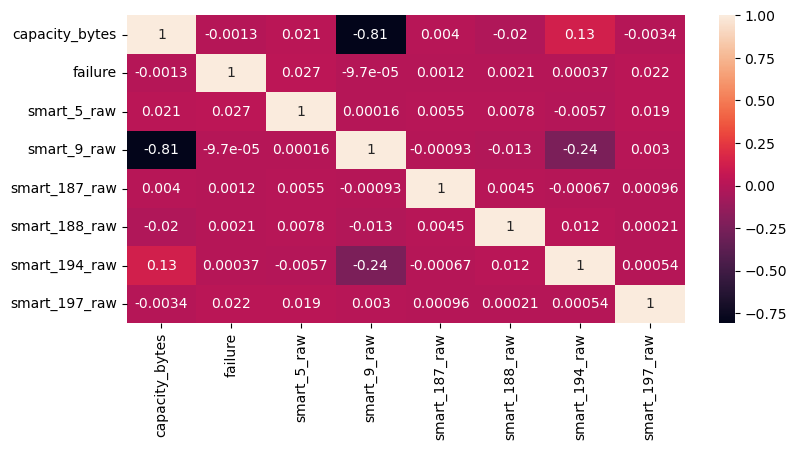

In [10]:
plt.figure(figsize=(9,4))
sns.heatmap(data,annot=True)
plt.show()

In [11]:
# Step 1: Convert power-on hours into age in days
df["age_days"] = df["smart_9_raw"] / 24

# Quick check - see the new column
df[["smart_9_raw", "age_days"]].head()

,smart_9_raw,age_days
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [12]:
# Step 2: Create age buckets
age_bins = [0, 100, 200, 365, 500, 750, 1000, 1500, 2000, 3000]
df["age_bucket"] = pd.cut(df["age_days"], bins=age_bins)

# Quick check - see which bucket each row fell into
df[["age_days", "age_bucket"]].head()

,age_days,age_bucket
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [13]:
# Step 3: Calculate failure rate per age bucket
failure_rate_by_age = df.groupby("age_bucket", observed=True)["failure"].mean() * 100

# This shows failure rate (%) for each age bucket
failure_rate_by_age

age_bucket
(0, 100]        0.003349
(100, 200]      0.003767
(200, 365]      0.001759
(365, 500]      0.002142
(500, 750]      0.003553
(750, 1000]     0.003975
(1000, 1500]    0.002127
(1500, 2000]    0.003510
(2000, 3000]    0.003869
Name: failure, dtype: float64

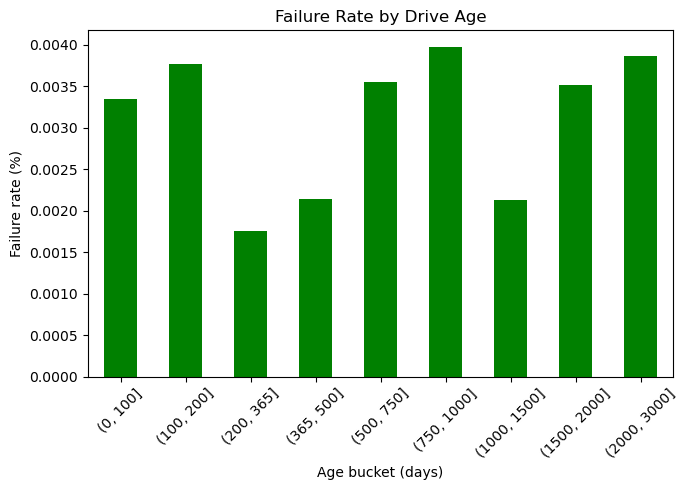

In [14]:
# Step 4 (optional): Plot it
import matplotlib.pyplot as plt

failure_rate_by_age.plot(kind="bar", figsize=(7,5), color="green")
plt.title("Failure Rate by Drive Age")
plt.xlabel("Age bucket (days)")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Step 1: Count total drive-days per model (how much data we have per model)
total_by_model = df.groupby("model")["failure"].count()

# Step 2: Count total failures per model
failures_by_model = df.groupby("model")["failure"].sum()

# Step 3: Calculate failure rate (%) per model
failure_rate_by_model = (failures_by_model / total_by_model) * 100

# Step 4: Only look at models with a meaningful amount of data
# (avoid models with just a handful of drives skewing the rate)
reliable_models = total_by_model[total_by_model > 10000].index
failure_rate_by_model_filtered = failure_rate_by_model[reliable_models]

# Step 5: Sort to see worst and best models
failure_rate_by_model_filtered.sort_values(ascending=False).head(15)

model
TOSHIBA MQ01ABF050      0.079247
ST500LM012 HN           0.025453
ST500LM030              0.022283
WDC WD5000LPVX          0.021564
TOSHIBA MQ01ABF050M     0.018906
ST16000NM001G           0.009554
ST12000NM001G           0.005800
ST4000DM000             0.003358
TOSHIBA MG07ACA14TA     0.003203
ST12000NM0007           0.003110
ST8000NM0055            0.003002
ST12000NM0008           0.002758
ST10000NM0086           0.002747
ST8000DM002             0.001964
HGST HUH721212ALN604    0.001671
Name: failure, dtype: float64

In [16]:
# How many unique drives and actual failure count for the worst model
worst_model = "TOSHIBA MQ01ABF050"

model_data = df[df["model"] == worst_model]

print("Unique drives:", model_data["serial_number"].nunique())
print("Total drive-days:", len(model_data))
print("Total failures:", model_data["failure"].sum())

Unique drives: 452
Total drive-days: 75713
Total failures: 60


In [17]:
sample = pd.read_csv("data/data_Q1_2020/2020-01-01.csv", low_memory=False)

In [18]:
"smart_194_raw" in sample.columns

True

In [19]:
sample["smart_194_raw"].isnull().sum()

np.int64(60)

In [20]:
sample["smart_194_raw"].notnull().sum()

np.int64(124895)

In [21]:
sample["smart_194_raw"].dropna().head(10)

0    22.0
1    28.0
2    29.0
3    25.0
4    28.0
5    32.0
6    20.0
7    31.0
8    22.0
9    33.0
Name: smart_194_raw, dtype: float64

In [22]:
# Step 1: Create temperature buckets
temp_bins = [0, 20, 25, 30, 35, 40, 45, 50, 60, 100]
df["temp_bucket"] = pd.cut(df["smart_194_raw"], bins=temp_bins)

# Step 2: Calculate failure rate per temperature bucket
failure_rate_by_temp = df.groupby("temp_bucket", observed=True)["failure"].mean() * 100

failure_rate_by_temp

temp_bucket
(0, 20]      0.003353
(20, 25]     0.002937
(25, 30]     0.002776
(30, 35]     0.002748
(35, 40]     0.003169
(40, 45]     0.005808
(45, 50]     0.008885
(50, 60]     0.029762
(60, 100]    0.000000
Name: failure, dtype: float64

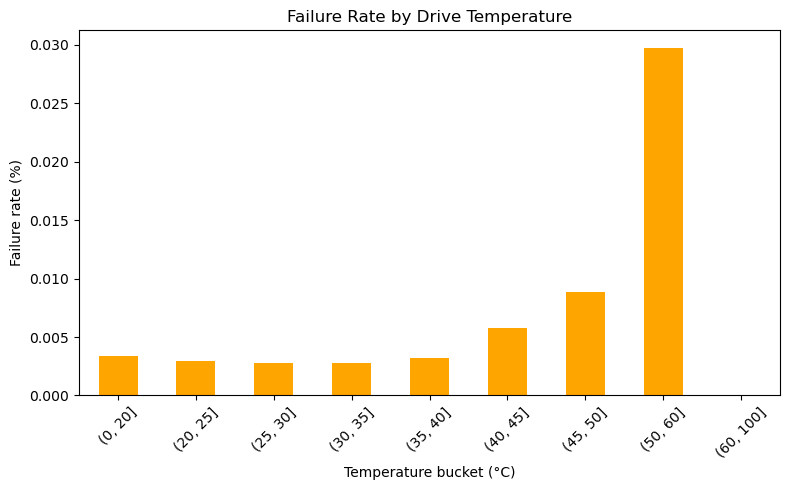

In [23]:
# Step 3: Plot it
import matplotlib.pyplot as plt

failure_rate_by_temp.plot(kind="bar", figsize=(8,5), color="orange")
plt.title("Failure Rate by Drive Temperature")
plt.xlabel("Temperature bucket (°C)")
plt.ylabel("Failure rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
df["temp_bucket"].value_counts()

temp_bucket
(25, 30]     7817980
(20, 25]     5855811
(30, 35]     5568105
(35, 40]     2335187
(0, 20]      1789399
(40, 45]      619878
(45, 50]       90042
(50, 60]        6720
(60, 100]          3
Name: count, dtype: int64

In [25]:
# Step A: Find each drive's failure date (if it has one)
failure_dates = df[df["failure"] == 1][["serial_number", "date"]].rename(
    columns={"date": "failure_date"}
)

# Check: how many drives actually have a failure date recorded
failure_dates.shape

(723, 2)

In [26]:
# Step B: Attach that failure date to every row of that drive
df = df.merge(failure_dates, on="serial_number", how="left")

# Check: peek at a drive that actually failed, to see the failure_date column filled in
df[df["failure_date"].notna()].head(10)

,date,serial_number,model,capacity_bytes,failure,smart_5_raw,smart_9_raw,smart_187_raw,smart_188_raw,smart_194_raw,smart_197_raw,age_days,age_bucket,temp_bucket,failure_date
8001,2020-02-20,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,181.0,NaN,NaN,41.0,0.0,7.541667,"(0, 100]","(40, 45]",2020-03-26
8002,2020-02-21,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,205.0,NaN,NaN,30.0,0.0,8.541667,"(0, 100]","(25, 30]",2020-03-26
8003,2020-02-22,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,221.0,NaN,NaN,30.0,0.0,9.208333,"(0, 100]","(25, 30]",2020-03-26
8004,2020-02-23,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,253.0,NaN,NaN,31.0,0.0,10.541667,"(0, 100]","(30, 35]",2020-03-26
8005,2020-02-24,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,268.0,NaN,NaN,30.0,0.0,11.166667,"(0, 100]","(25, 30]",2020-03-26
8006,2020-02-25,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,300.0,NaN,NaN,30.0,0.0,12.500000,"(0, 100]","(25, 30]",2020-03-26
8007,2020-02-26,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,316.0,NaN,NaN,30.0,0.0,13.166667,"(0, 100]","(25, 30]",2020-03-26
8008,2020-02-27,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,348.0,NaN,NaN,30.0,0.0,14.500000,"(0, 100]","(25, 30]",2020-03-26
8009,2020-02-28,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,364.0,NaN,NaN,28.0,0.0,15.166667,"(0, 100]","(25, 30]",2020-03-26
8010,2020-02-29,10A0A042F97G,TOSHIBA MG07ACA14TA,14000519643136,0,0.0,395.0,NaN,NaN,29.0,0.0,16.458333,"(0, 100]","(25, 30]",2020-03-26


In [27]:
# Step C: Calculate days until failure
df["days_until_failure"] = (df["failure_date"] - df["date"]).dt.days

# Check: look at the distribution for a failed drive
df[df["failure_date"].notna()][["date", "failure_date", "days_until_failure"]].head(20)

,date,failure_date,days_until_failure
8001,2020-02-20,2020-03-26,35.0
8002,2020-02-21,2020-03-26,34.0
8003,2020-02-22,2020-03-26,33.0
8004,2020-02-23,2020-03-26,32.0
8005,2020-02-24,2020-03-26,31.0
8006,2020-02-25,2020-03-26,30.0
8007,2020-02-26,2020-03-26,29.0
8008,2020-02-27,2020-03-26,28.0
8009,2020-02-28,2020-03-26,27.0
8010,2020-02-29,2020-03-26,26.0


In [28]:
# Step D: Create the 7-day label
df["will_fail_7d"] = ((df["days_until_failure"] >= 0) & (df["days_until_failure"] <= 7)).astype(int)

# Check: how many rows got labeled as "will fail within 7 days"
df["will_fail_7d"].value_counts()

will_fail_7d
0    24095919
1        5535
Name: count, dtype: int64

In [29]:
# Create the 30-day label (reusing days_until_failure from before)
df["will_fail_30d"] = ((df["days_until_failure"] >= 0) & (df["days_until_failure"] <= 30)).astype(int)

# Check: how many rows got labeled as "will fail within 30 days"
df["will_fail_30d"].value_counts()

will_fail_30d
0    24082215
1       19239
Name: count, dtype: int64

In [30]:
# Rolling 7-day mean and max for smart_5_raw, calculated per drive
df["smart_5_raw_roll7_mean"] = (
    df.groupby("serial_number")["smart_5_raw"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df["smart_5_raw_roll7_max"] = (
    df.groupby("serial_number")["smart_5_raw"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).max())
)

In [31]:
# Pick one drive and look at its rolling values over time
sample_drive = df[df["serial_number"] == df["serial_number"].iloc[0]]
sample_drive[["date", "smart_5_raw", "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max"]].head(15)

,date,smart_5_raw,smart_5_raw_roll7_mean,smart_5_raw_roll7_max
0,2020-04-23,NaN,NaN,NaN
1,2020-04-24,NaN,NaN,NaN
2,2020-04-25,NaN,NaN,NaN
3,2020-04-26,NaN,NaN,NaN
4,2020-04-27,NaN,NaN,NaN
5,2020-04-28,NaN,NaN,NaN
6,2020-04-29,NaN,NaN,NaN
7,2020-04-30,NaN,NaN,NaN
8,2020-05-01,NaN,NaN,NaN
9,2020-05-02,NaN,NaN,NaN


In [32]:
# Find a drive that actually has some non-null smart_5_raw values
drives_with_data = df[df["smart_5_raw"].notna()]["serial_number"].unique()
good_drive = drives_with_data[0]

sample_drive = df[df["serial_number"] == good_drive]
sample_drive[["date", "smart_5_raw", "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max"]].head(15)

,date,smart_5_raw,smart_5_raw_roll7_mean,smart_5_raw_roll7_max
68,2020-06-27,0.0,0.0,0.0
69,2020-06-28,0.0,0.0,0.0
70,2020-06-29,0.0,0.0,0.0
71,2020-06-30,0.0,0.0,0.0


In [33]:
# Find a drive that actually failed, and has some non-null smart_5_raw
failed_drives = df[(df["failure"] == 1) & (df["smart_5_raw"].notna())]["serial_number"].unique()
failed_drive = failed_drives[0]

sample_failed = df[df["serial_number"] == failed_drive]
sample_failed[["date", "smart_5_raw", "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max", "failure"]].tail(15)

,date,smart_5_raw,smart_5_raw_roll7_mean,smart_5_raw_roll7_max,failure
8022,2020-03-12,0.0,0.0,0.0,0
8023,2020-03-13,0.0,0.0,0.0,0
8024,2020-03-14,0.0,0.0,0.0,0
8025,2020-03-15,0.0,0.0,0.0,0
8026,2020-03-16,0.0,0.0,0.0,0
8027,2020-03-17,0.0,0.0,0.0,0
8028,2020-03-18,0.0,0.0,0.0,0
8029,2020-03-19,0.0,0.0,0.0,0
8030,2020-03-20,0.0,0.0,0.0,0
8031,2020-03-21,0.0,0.0,0.0,0


In [34]:
# Find a failed drive where smart_5_raw actually shows values > 0 at some point
drives_with_signal = df[(df["failure"] == 1) & (df["smart_5_raw"] > 0)]["serial_number"].unique()
print("Number of failed drives with non-zero smart_5_raw at some point:", len(drives_with_signal))

if len(drives_with_signal) > 0:
    demo_drive = drives_with_signal[0]
    demo_data = df[df["serial_number"] == demo_drive]
    print(demo_data[["date", "smart_5_raw", "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max", "failure"]].tail(15))

Number of failed drives with non-zero smart_5_raw at some point: 292
             date  smart_5_raw  smart_5_raw_roll7_mean  smart_5_raw_roll7_max  \
267746 2020-05-06        144.0              144.000000                  144.0   
267747 2020-05-07        144.0              144.000000                  144.0   
267748 2020-05-08        144.0              144.000000                  144.0   
267749 2020-05-09        184.0              149.714286                  184.0   
267750 2020-05-10        192.0              156.571429                  192.0   
267751 2020-05-11        192.0              163.428571                  192.0   
267752 2020-05-12        192.0              170.285714                  192.0   
267753 2020-05-13        200.0              178.285714                  200.0   
267754 2020-05-14        200.0              186.285714                  200.0   
267755 2020-05-15        200.0              194.285714                  200.0   
267756 2020-05-16        200.0          

In [35]:
# Build rolling 7-day mean and max for the remaining important columns
columns_to_roll = ["smart_187_raw", "smart_197_raw", "smart_194_raw"]

for col in columns_to_roll:
    df[f"{col}_roll7_mean"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    )
    df[f"{col}_roll7_max"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).max())
    )

print("Done. New columns added:")
print([c for c in df.columns if "roll7" in c])

Done. New columns added:
['smart_5_raw_roll7_mean', 'smart_5_raw_roll7_max', 'smart_187_raw_roll7_mean', 'smart_187_raw_roll7_max', 'smart_197_raw_roll7_mean', 'smart_197_raw_roll7_max', 'smart_194_raw_roll7_mean', 'smart_194_raw_roll7_max']


In [36]:
demo_data = df[df["serial_number"] == demo_drive]
demo_data[["date", "smart_187_raw", "smart_187_raw_roll7_mean", 
           "smart_197_raw", "smart_197_raw_roll7_mean",
           "smart_194_raw", "smart_194_raw_roll7_mean", "failure"]].tail(10)

,date,smart_187_raw,smart_187_raw_roll7_mean,smart_197_raw,smart_197_raw_roll7_mean,smart_194_raw,smart_194_raw_roll7_mean,failure
267751,2020-05-11,NaN,NaN,0.0,0.000000,30.0,30.428571,0
267752,2020-05-12,NaN,NaN,0.0,0.000000,30.0,30.428571,0
267753,2020-05-13,NaN,NaN,0.0,0.000000,30.0,30.285714,0
267754,2020-05-14,NaN,NaN,0.0,0.000000,30.0,30.285714,0
267755,2020-05-15,NaN,NaN,0.0,0.000000,29.0,30.000000,0
267756,2020-05-16,NaN,NaN,0.0,0.000000,30.0,30.000000,0
267757,2020-05-17,NaN,NaN,0.0,0.000000,30.0,29.857143,0
267758,2020-05-18,NaN,NaN,0.0,0.000000,30.0,29.857143,0
267759,2020-05-19,NaN,NaN,0.0,0.000000,30.0,29.857143,0
267760,2020-05-20,NaN,NaN,24.0,3.428571,30.0,29.857143,1


In [37]:
# Step 8: Time-based train/test split
train_cutoff = "2020-05-01"

train_df = df[df["date"] < train_cutoff]
test_df = df[df["date"] >= train_cutoff]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

print("\nTrain failure count (will_fail_7d):", train_df["will_fail_7d"].sum())
print("Test failure count (will_fail_7d):", test_df["will_fail_7d"].sum())

Train shape: (15618819, 26)
Test shape: (8482635, 26)
Train date range: 2020-01-01 00:00:00 to 2020-04-30 00:00:00
Test date range: 2020-05-01 00:00:00 to 2020-06-30 00:00:00

Train failure count (will_fail_7d): 4045
Test failure count (will_fail_7d): 1490


In [38]:
import os
import psutil 
process = psutil.Process(os.getpid())
print("jupyter kernel memory:", round(process.memory_info().rss / 1024**3,2),"GB")

jupyter kernel memory: 1.81 GB


In [39]:
# Define features and target
feature_cols = [
    "capacity_bytes",
    "smart_5_raw", "smart_187_raw", "smart_197_raw", "smart_194_raw",
    "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max",
    "smart_187_raw_roll7_mean", "smart_187_raw_roll7_max",
    "smart_197_raw_roll7_mean", "smart_197_raw_roll7_max",
    "smart_194_raw_roll7_mean", "smart_194_raw_roll7_max",
]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["will_fail_7d"]

X_test = test_df[feature_cols].fillna(0)
y_test = test_df["will_fail_7d"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train failure rate:", y_train.mean())
print("y_test failure rate:", y_test.mean())

X_train shape: (15618819, 13)
X_test shape: (8482635, 13)
y_train failure rate: 0.00025898244931322914
y_test failure rate: 0.00017565296632473282


In [40]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import xgboost as xgb
from lifelines import CoxPHFitter
import pandas as pd

# ==========================================
# STEP 9: Baseline Logistic Regression
# ==========================================
print("=== STEP 9: Logistic Regression (Baseline) ===")
start = time.time()

log_model = LogisticRegression(class_weight="balanced", max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_proba_log = log_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))
print("PR-AUC:", average_precision_score(y_test, y_proba_log))
print(f"Time taken: {round(time.time() - start, 1)}s\n")


# ==========================================
# STEP 10: XGBoost (Main Model)
# ==========================================
print("=== STEP 10: XGBoost ===")
start = time.time()

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    eval_metric="aucpr",
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
print("PR-AUC:", average_precision_score(y_test, y_proba_xgb))
print(f"Time taken: {round(time.time() - start, 1)}s\n")


# ==========================================
# STEP 11: Survival Analysis (Cox Proportional Hazards)
# ==========================================
print("=== STEP 11: Cox Proportional Hazards (Survival Analysis) ===")
start = time.time()

survival_sample = train_df.sample(n=min(200000, len(train_df)), random_state=42)

# FIX: drop smart_197_raw (caused matrix singularity - too sparse in the sample)
survival_features = [c for c in feature_cols if c != "smart_197_raw"]
survival_cols = survival_features + ["days_until_failure", "failure"]
survival_data = survival_sample[survival_cols].fillna(0)

survival_data = survival_data[survival_data["days_until_failure"].notna()]
survival_data["days_until_failure"] = survival_data["days_until_failure"].clip(lower=0.1)

# FIX: added penalizer to stabilize the model against collinearity
cph = CoxPHFitter(penalizer=0.1)
cph.fit(survival_data, duration_col="days_until_failure", event_col="failure")

print(cph.summary[["coef", "exp(coef)", "p"]])
print(f"Time taken: {round(time.time() - start, 1)}s\n")

print("=== ALL PHASE 4 STEPS COMPLETE ===")

=== STEP 9: Logistic Regression (Baseline) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   8481145
           1       0.00      0.00      0.00      1490

    accuracy                           1.00   8482635
   macro avg       0.50      0.50      0.50   8482635
weighted avg       1.00      1.00      1.00   8482635

ROC-AUC: 0.5645654091889052
PR-AUC: 0.00035938076101988705
Time taken: 22.5s

=== STEP 10: XGBoost ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   8481145
           1       0.00      0.54      0.00      1490

    accuracy                           0.95   8482635
   macro avg       0.50      0.74      0.49   8482635
weighted avg       1.00      0.95      0.98   8482635

ROC-AUC: 0.7828483510012327
PR-AUC: 0.020370349015438757
Time taken: 24.8s

=== STEP 11: Cox Proportional Hazards (Survival Analysis) ===
                                  coef  exp(coef)         

Best threshold: 0.99
Minimum total cost: $2,989,100
Cost at default threshold (0.5): $42,096,800
Savings from optimizing threshold: $39,107,700


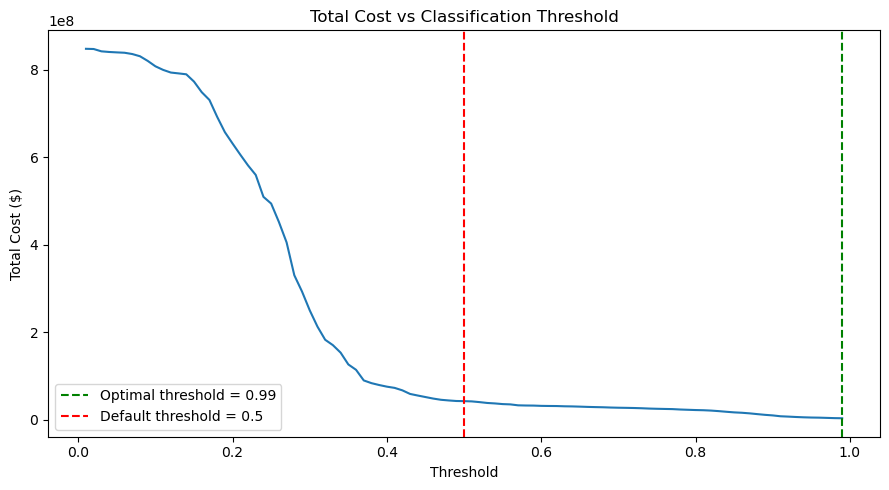

In [41]:
import numpy as np
import matplotlib.pyplot as plt
# Assign cost values (adjust these if you want different assumptions)
COST_FALSE_NEGATIVE = 2000   # missed failure: data loss, downtime, SLA violation
COST_FALSE_POSITIVE = 100    # early replacement: wasted but cheap

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    
    false_negatives = ((y_pred_t == 0) & (y_test == 1)).sum()
    false_positives = ((y_pred_t == 1) & (y_test == 0)).sum()
    
    total_cost = (false_negatives * COST_FALSE_NEGATIVE) + (false_positives * COST_FALSE_POSITIVE)
    costs.append(total_cost)

costs = np.array(costs)
best_threshold_idx = np.argmin(costs)
best_threshold = thresholds[best_threshold_idx]
best_cost = costs[best_threshold_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Minimum total cost: ${best_cost:,.0f}")

# Compare to default threshold (0.5)
default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f"Cost at default threshold (0.5): ${costs[default_idx]:,.0f}")
print(f"Savings from optimizing threshold: ${costs[default_idx] - best_cost:,.0f}")

# Plot cost vs threshold
plt.figure(figsize=(9, 5))
plt.plot(thresholds, costs)
plt.axvline(best_threshold, color="green", linestyle="--", label=f"Optimal threshold = {best_threshold:.2f}")
plt.axvline(0.5, color="red", linestyle="--", label="Default threshold = 0.5")
plt.title("Total Cost vs Classification Threshold")
plt.xlabel("Threshold")
plt.ylabel("Total Cost ($)")
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
y_pred_best = (y_proba_xgb >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   8481145
           1       0.05      0.11      0.07      1490

    accuracy                           1.00   8482635
   macro avg       0.52      0.56      0.53   8482635
weighted avg       1.00      1.00      1.00   8482635



In [43]:
COST_FALSE_NEGATIVE = 5000   # missed failure: data loss, downtime, SLA violation, potential customer impact
COST_FALSE_POSITIVE = 50     # early replacement: drive cost is often a small fraction of total cost

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    false_negatives = ((y_pred_t == 0) & (y_test == 1)).sum()
    false_positives = ((y_pred_t == 1) & (y_test == 0)).sum()
    total_cost = (false_negatives * COST_FALSE_NEGATIVE) + (false_positives * COST_FALSE_POSITIVE)
    costs.append(total_cost)

costs = np.array(costs)
best_threshold_idx = np.argmin(costs)
best_threshold = thresholds[best_threshold_idx]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Minimum total cost: ${costs[best_threshold_idx]:,.0f}")

y_pred_best = (y_proba_xgb >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))

Best threshold: 0.97
Minimum total cost: $6,470,550
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   8481145
           1       0.02      0.23      0.04      1490

    accuracy                           1.00   8482635
   macro avg       0.51      0.62      0.52   8482635
weighted avg       1.00      1.00      1.00   8482635



In [44]:
MIN_RECALL = 0.60  # require catching at least 60% of real failures

thresholds = np.arange(0.01, 1.0, 0.01)
results = []

for t in thresholds:
    y_pred_t = (y_proba_xgb >= t).astype(int)
    
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    
    results.append({"threshold": t, "recall": recall, "cost": total_cost, "fp": fp, "fn": fn})

results_df = pd.DataFrame(results)

# Only keep thresholds meeting the minimum recall requirement
valid = results_df[results_df["recall"] >= MIN_RECALL]

if len(valid) > 0:
    best_row = valid.loc[valid["cost"].idxmin()]
    print(f"Best threshold meeting {MIN_RECALL:.0%} recall requirement: {best_row['threshold']:.2f}")
    print(f"Achieved recall: {best_row['recall']:.2%}")
    print(f"Total cost: ${best_row['cost']:,.0f}")
    print(f"False positives: {int(best_row['fp'])}, False negatives: {int(best_row['fn'])}")
    
    y_pred_constrained = (y_proba_xgb >= best_row["threshold"]).astype(int)
    print(classification_report(y_test, y_pred_constrained))
else:
    print(f"No threshold achieves {MIN_RECALL:.0%} recall. Max achievable recall:", results_df["recall"].max())

Best threshold meeting 60% recall requirement: 0.36
Achieved recall: 62.28%
Total cost: $59,098,400
False positives: 1125768, False negatives: 562
              precision    recall  f1-score   support

           0       1.00      0.87      0.93   8481145
           1       0.00      0.62      0.00      1490

    accuracy                           0.87   8482635
   macro avg       0.50      0.75      0.47   8482635
weighted avg       1.00      0.87      0.93   8482635



In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, average_precision_score
import xgboost as xgb
import time

# Use a SAMPLE for tuning, not the full 24M rows
sample_size = 500000
sample_idx = X_train.sample(n=min(sample_size, len(X_train)), random_state=42).index
X_train_sample = X_train.loc[sample_idx]
y_train_sample = y_train.loc[sample_idx]

print("Tuning on sample size:", len(X_train_sample))
start = time.time()

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6],
    "learning_rate": [0.1, 0.2],
}

scale_pos_weight = (y_train_sample == 0).sum() / (y_train_sample == 1).sum()

base_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42
)

pr_auc_scorer = make_scorer(average_precision_score, needs_proba=True)

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=5,        # fewer combinations
    scoring=pr_auc_scorer,
    cv=2,            # fewer folds
    verbose=2,
    random_state=42,
    n_jobs=1         # IMPORTANT: single core, not all cores at once - safer on memory
)

search.fit(X_train_sample, y_train_sample)

print(f"\nSearch completed in {round(time.time()-start, 1)}s")
print("Best parameters found:", search.best_params_)

Tuning on sample size: 500000
Fitting 2 folds for each of 5 candidates, totalling 10 fits
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   0.7s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=200; total time=   0.7s
[CV] END ...learning_rate=0.2, max_depth=4, n_estimators=200; total time=   0.7s
[CV] END ...learning_rate=0.2, max_depth=4, n_estimators=200; total time=   0.8s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=100; total time=   0.4s
[CV] END ...learning_rate=0.1, max_depth=4, n_estimators=100; total time=   0.5s
[CV] END ...learning_rate=0.2, max_depth=6, n_estimators=200; total time=   0.9s
[CV] END ...learning_rate=0.2, max_depth=6, n_estimators=200; total time=   0.9s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=100; total time=   0.5s
[CV] END ...learning_rate=0.1, max_depth=6, n_estimators=100; total time=   0.5s

Search completed in 8.0s
Best parameters found: {'n_estimators': 200, 'max_depth': 4, 'learning_rat

In [46]:
best_params = search.best_params_

final_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42
)
final_model.fit(X_train, y_train)

y_proba_final = final_model.predict_proba(X_test)[:, 1]
y_pred_final = final_model.predict(X_test)

print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_final))
print("PR-AUC:", average_precision_score(y_test, y_proba_final))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   8481145
           1       0.00      0.53      0.00      1490

    accuracy                           0.95   8482635
   macro avg       0.50      0.74      0.49   8482635
weighted avg       1.00      0.95      0.97   8482635

ROC-AUC: 0.7916516702678185
PR-AUC: 0.01494432522264936


In [47]:
for col in ["smart_9_raw", "smart_188_raw"]:
    df[f"{col}_roll7_mean"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
    )
    df[f"{col}_roll7_max"] = (
        df.groupby("serial_number")[col]
        .transform(lambda x: x.rolling(window=7, min_periods=1).max())
    )
    print(f"Done: {col}")

Done: smart_9_raw
Done: smart_188_raw


In [48]:
train_df = df[df["date"] < train_cutoff]
test_df = df[df["date"] >= train_cutoff]
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (15618819, 30)
Test shape: (8482635, 30)


In [49]:
feature_cols = [
    "capacity_bytes",
    "smart_5_raw", "smart_187_raw", "smart_197_raw", "smart_194_raw",
    "smart_9_raw", "smart_188_raw",
    "smart_5_raw_roll7_mean", "smart_5_raw_roll7_max",
    "smart_187_raw_roll7_mean", "smart_187_raw_roll7_max",
    "smart_197_raw_roll7_mean", "smart_197_raw_roll7_max",
    "smart_194_raw_roll7_mean", "smart_194_raw_roll7_max",
    "smart_9_raw_roll7_mean", "smart_9_raw_roll7_max",
    "smart_188_raw_roll7_mean", "smart_188_raw_roll7_max",
]

X_train = train_df[feature_cols].fillna(0)
y_train = train_df["will_fail_7d"]
X_test = test_df[feature_cols].fillna(0)
y_test = test_df["will_fail_7d"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (15618819, 19)
X_test shape: (8482635, 19)


In [50]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model_v2 = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,  # using your tuned settings
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42
)
xgb_model_v2.fit(X_train, y_train)

y_pred_v2 = xgb_model_v2.predict(X_test)
y_proba_v2 = xgb_model_v2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_v2))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_v2))
print("PR-AUC:", average_precision_score(y_test, y_proba_v2))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95   8481145
           1       0.00      0.57      0.00      1490

    accuracy                           0.91   8482635
   macro avg       0.50      0.74      0.48   8482635
weighted avg       1.00      0.91      0.95   8482635

ROC-AUC: 0.8082039997045004
PR-AUC: 0.008990921610715769


In [51]:
COST_FALSE_NEGATIVE = 5000
COST_FALSE_POSITIVE = 50
MIN_RECALL = 0.60

thresholds = np.arange(0.01, 1.0, 0.01)
results_v2 = []

for t in thresholds:
    y_pred_t = (y_proba_v2 >= t).astype(int)
    
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    total_cost = (fn * COST_FALSE_NEGATIVE) + (fp * COST_FALSE_POSITIVE)
    
    results_v2.append({"threshold": t, "recall": recall, "cost": total_cost, "fp": fp, "fn": fn})

results_df_v2 = pd.DataFrame(results_v2)

valid_v2 = results_df_v2[results_df_v2["recall"] >= MIN_RECALL]

if len(valid_v2) > 0:
    best_row_v2 = valid_v2.loc[valid_v2["cost"].idxmin()]
    print(f"Best threshold meeting {MIN_RECALL:.0%} recall requirement: {best_row_v2['threshold']:.2f}")
    print(f"Achieved recall: {best_row_v2['recall']:.2%}")
    print(f"Total cost: ${best_row_v2['cost']:,.0f}")
    print(f"False positives: {int(best_row_v2['fp'])}, False negatives: {int(best_row_v2['fn'])}")
    
    y_pred_constrained_v2 = (y_proba_v2 >= best_row_v2["threshold"]).astype(int)
    print(classification_report(y_test, y_pred_constrained_v2))
else:
    print(f"No threshold achieves {MIN_RECALL:.0%} recall. Max achievable recall:", results_df_v2["recall"].max())

Best threshold meeting 60% recall requirement: 0.45
Achieved recall: 60.47%
Total cost: $51,871,750
False positives: 978535, False negatives: 589
              precision    recall  f1-score   support

           0       1.00      0.88      0.94   8481145
           1       0.00      0.60      0.00      1490

    accuracy                           0.88   8482635
   macro avg       0.50      0.74      0.47   8482635
weighted avg       1.00      0.88      0.94   8482635



In [52]:
import joblib

# Save the trained model (v2 - improved with smart_9 and smart_188)
joblib.dump(xgb_model_v2, "xgb_model.pkl")

# Build a small results table: just what the dashboard needs to display
results_table = test_df[["serial_number", "model", "date"]].copy()
results_table["failure_probability"] = y_proba_v2
results_table["actual_failure_7d"] = y_test.values

# Keep only the most recent day per drive, sorted by risk - keeps the file small
latest_per_drive = results_table.sort_values("date").groupby("serial_number").tail(1)
latest_per_drive = latest_per_drive.sort_values("failure_probability", ascending=False)

latest_per_drive.to_csv("dashboard_data.csv", index=False)
print("Saved model and dashboard data. Rows:", len(latest_per_drive))

Saved model and dashboard data. Rows: 144706


In [53]:
import json

# Save key metrics for the dashboard to display (v2 model)
metrics = {
    "total_drives_monitored": int(test_df["serial_number"].nunique()),
    "total_test_failures": int(y_test.sum()),
    "model_recall": float(best_row_v2["recall"]),
    "model_roc_auc": float(roc_auc_score(y_test, y_proba_v2)),
    "chosen_threshold": float(best_row_v2["threshold"]),
}
with open("dashboard_metrics.json", "w") as f:
    json.dump(metrics, f)

# Save the cost-vs-threshold data for the chart (v2 model)
cost_curve_df = results_df_v2[["threshold", "recall", "cost"]]
cost_curve_df.to_csv("cost_curve_data.csv", index=False)

print("Saved metrics and cost curve data.")

Saved metrics and cost curve data.
